# 📈 Exploratory Data Analysis - LogisChain AI

Welcome to the **Exploratory Data Analysis (EDA)** notebook for the LogisChain AI project. In this notebook, we perform the Phase 1 EDA deliverables:
1. **Supply Chain Network Visualisation**: Construct a trade flow graph using `NetworkX` showing node structures.
2. **Temporal Pattern Analysis**: Decompose seasonal patterns in port throughput and freight indices.
3. **Cross-Domain Correlation Analysis**: Map relationships between operational supply chain metrics (OTIF) and corporate default signals.

In [1]:
import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

%matplotlib inline
sns.set_theme(style="darkgrid", palette="muted")

## 1. Load Raw Datasets

In [2]:
raw_dir = "../data/raw"
df_financials = pd.read_csv(os.path.join(raw_dir, "financial_metrics.csv"))
df_shipments = pd.read_csv(os.path.join(raw_dir, "shipments.csv"))
df_customs = pd.read_csv(os.path.join(raw_dir, "customs_declarations.csv"))
df_ports = pd.read_csv(os.path.join(raw_dir, "port_throughput.csv"))
df_freight = pd.read_csv(os.path.join(raw_dir, "freight_rates.csv"))

print(f"Financials loaded: {df_financials.shape}")
print(f"Shipments loaded: {df_shipments.shape}")
print(f"Ports telemetry loaded: {df_ports.shape}")

Financials loaded: (20, 11)
Shipments loaded: (2500, 18)
Ports telemetry loaded: (2920, 8)


## 2. Supply Chain Graph Network Visualisation

d:\Internship\Zetheta Algorithms Private Limited\Data Scientist LogisChain AI\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


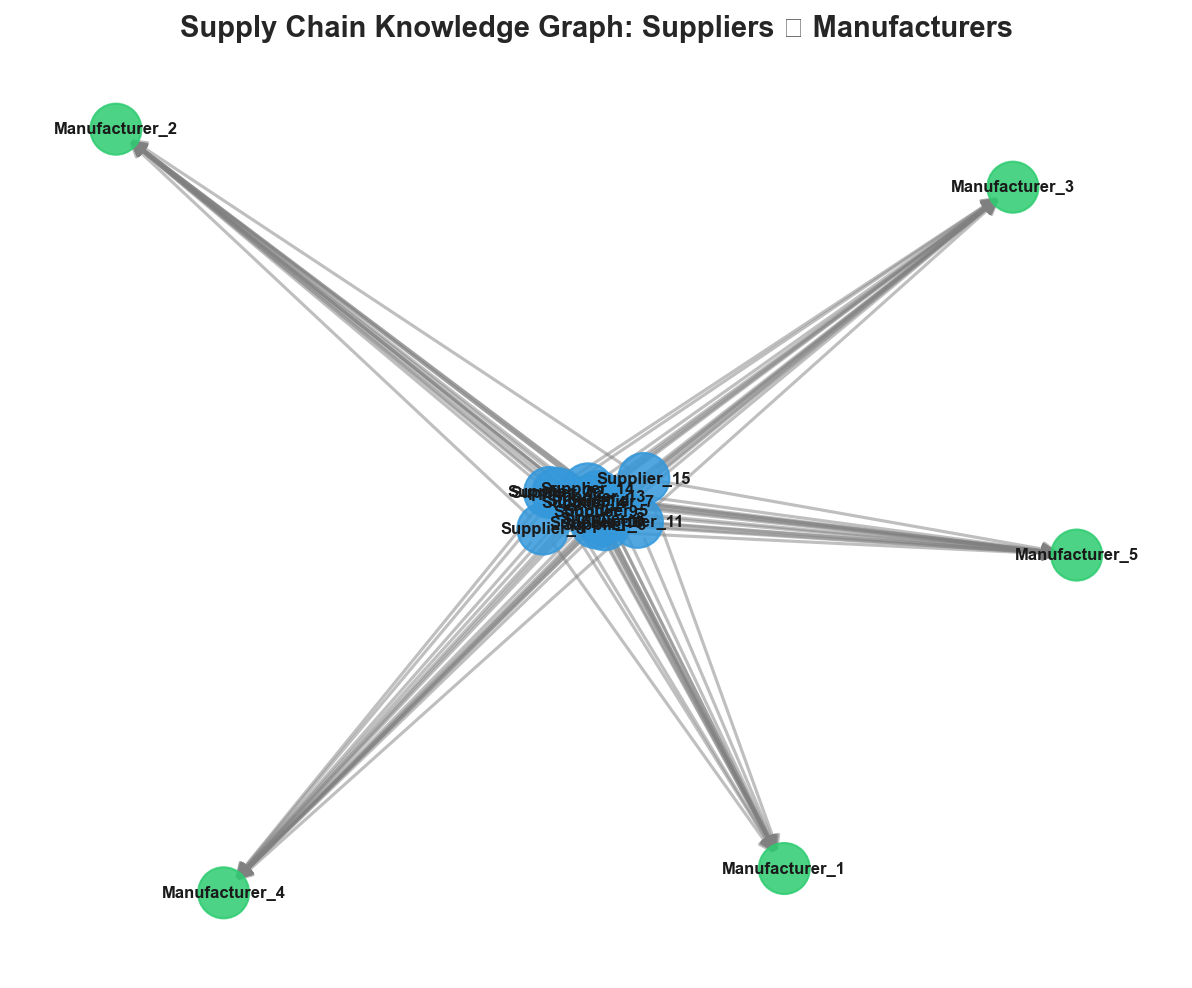

In [3]:
G = nx.DiGraph()
for _, row in df_financials.iterrows():
    G.add_node(row["company_name"], type=row["company_type"])

trade_flows = df_customs.groupby(["exporter", "importer"])["invoice_value_usd"].sum().reset_index()
for _, row in trade_flows.iterrows():
    if G.has_node(row["exporter"]) and G.has_node(row["importer"]):
        G.add_edge(row["exporter"], row["importer"], weight=row["invoice_value_usd"])

plt.figure(figsize=(10, 8), dpi=150)
pos = nx.spring_layout(G, k=0.5, seed=42)
node_colors = ["#3498db" if G.nodes[n]["type"] == "Supplier" else "#2ecc71" for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, alpha=0.85)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.5, edge_color="gray", arrowsize=15)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")

plt.title("Supply Chain Knowledge Graph: Suppliers ➔ Manufacturers", fontsize=14, fontweight="bold")
plt.axis("off")
plt.show()

## 3. Temporal Pattern Analysis & Time Series Decomposition

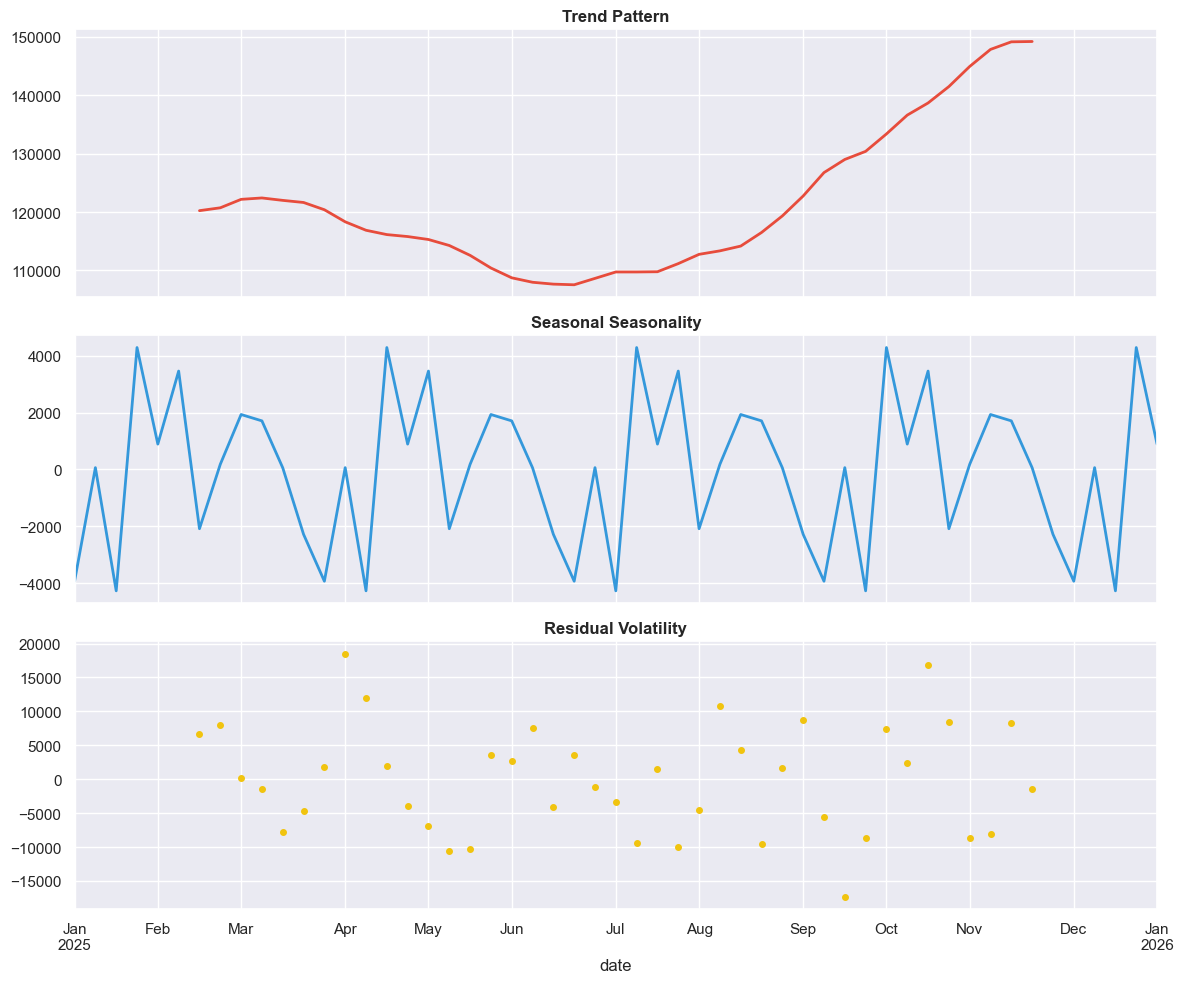

In [4]:
# Filter to a single port and examine container throughput
sh_throughput = df_ports[df_ports["port_code"] == "CNSHA"].copy()
sh_throughput["date"] = pd.to_datetime(sh_throughput["date"])
sh_throughput.set_index("date", inplace=True)
sh_throughput = sh_throughput["throughput_teu"].resample("W").mean()

# Decompose weekly port throughput
decomposition = seasonal_decompose(sh_throughput, model='additive', period=12)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
decomposition.trend.plot(ax=ax1, color="#e74c3c", lw=2)
ax1.set_title("Trend Pattern", fontweight="bold")
decomposition.seasonal.plot(ax=ax2, color="#3498db", lw=2)
ax2.set_title("Seasonal Seasonality", fontweight="bold")
decomposition.resid.plot(ax=ax3, color="#f1c40f", style=".", markersize=8)
ax3.set_title("Residual Volatility", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Cross-Domain Correlation Analysis

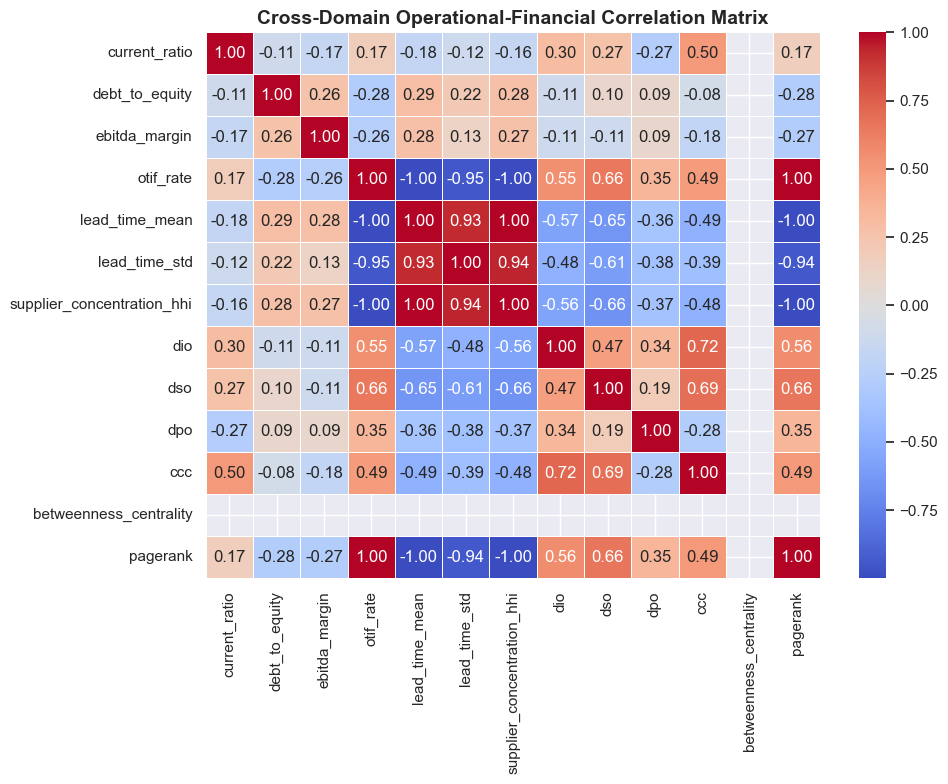

In [5]:
# Load precomputed master features to plot correlation structure
df_feats = pd.read_csv("../data/features/master_features.csv")
num_cols = [
    "current_ratio", "debt_to_equity", "ebitda_margin", 
    "otif_rate", "lead_time_mean", "lead_time_std", 
    "supplier_concentration_hhi", "dio", "dso", "dpo", "ccc",
    "betweenness_centrality", "pagerank"
]

corr_matrix = df_feats[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Cross-Domain Operational-Financial Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()